In [18]:

models = ["gpt_5_1", "gemini_2_5_pro", "qwen_3_235b_thinking"]

In [19]:
import pandas as pd
def load_json(file_path):
    return pd.read_json(file_path)

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def threat_chart(base_model_dir, stats_dir, application):
    # Axis tick label size
    plt.rcParams["xtick.labelsize"] = 12
    plt.rcParams["ytick.labelsize"] = 12

    # Axis label size
    plt.rcParams["axes.labelsize"] = 13

    # Title size
    plt.rcParams["axes.titlesize"] = 14

    # Legend size
    plt.rcParams["legend.fontsize"] = 14
        
    original_df = load_json(f"{base_model_dir}/threat_model.json")
    data = load_json(f"{stats_dir}/similarity_summary.json")

    models = list(data.keys())
    n_models = len(models)

    # Bar positions
    group_width = 0.6  # width of a model group
    bar_width = group_width / 3  # three bars per model
    x = np.arange(n_models)

    # Colors
    colors_simple = ["#A3D977", "#A167C9"]  # threats, mitigations
    colors_risk = ["#B3D3F2", "#7FB5E1", "#4F94D4"]  # risk_less, risk_same, risk_more

    fig, ax = plt.subplots(figsize=(8, 4))

    for i, model in enumerate(models):
        # Threats bar
        ax.bar(x[i] - bar_width, data[model]["threats"], width=bar_width, color=colors_simple[0], label="Threats" if i==0 else "")
        
        # Mitigations bar
        ax.bar(x[i], data[model]["mitigations"], width=bar_width, color=colors_simple[1], label="Mitigations" if i==0 else "")
        
        # Risks stacked bar
        risk_bottom = 0
        for j, key in enumerate(["risk_less", "risk_same", "risk_more"]):
            ax.bar(x[i] + bar_width, data[model][key], width=bar_width, bottom=risk_bottom, color=colors_risk[j], label=key.replace("_"," ").title() if i==0 else "")
            risk_bottom += data[model][key]

    # Labels
    label_map = {
        "gpt_5_1": "GPT-5.1",
        "gemini_2_5_pro": "Gemini 2.5 Pro",
        "qwen_3_235b_thinking": "Qwen-3 235B"
    }

    ax.set_xticks(x)
    ax.set_xticklabels([label_map[m] for m in models], rotation=30, ha="right")
    ax.set_ylabel("Threats in Baseline Model")
    ax.set_ybound(0, len(original_df))

    # Legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"{stats_dir}/{application}_results.pdf", dpi=300)
    plt.show()


In [21]:
import re
import json

ASSET_KEYWORDS = {
    "Service", "Server", "Database", "Storage", "Queue", "Worker",
    "Application", "API", "UI", "Web", "Hub", "Device", "Browser",
    "Container", "Runtime", "Module", "Gateway", "Camera"
}
SINGLE_WORD_STOPWORDS = {
    # adjectives
    "Unauthorized", "Malicious", "Legitimate", "Complete", "Full",
    "Corrupted", "Compromised", "Improper", "Insufficient",

    # abstract nouns
    "Exposure", "Difficulty", "Loss", "Error", "Degradation",

    # actors / roles
    "Attacker", "Attackers", "Administrators", "Users", "Personnel",
    "Client", "Business",

    # logic / filler
    "If", "By", "For", "Since", "When", "Would", "Could", "Should",
}
LEADING_STOPWORDS = {
    "The", "A", "An", "If", "By", "For", "Since", "When", "Because",
    "Without", "Under", "With", "Any", "All", "Another"
}

def is_valid_asset(phrase: str, known_assets: set) -> bool:
    words = phrase.split()

    # Leading stopwords
    if words[0] in LEADING_STOPWORDS:
        return False

    # Single-word stopwords
    if len(words) == 1 and words[0] in SINGLE_WORD_STOPWORDS:
        return False

    # All-caps rule
    if all(w.isupper() for w in words) and len(words) < 2:
        return False

    # Structure rule
    if len(words) > 1:
        if not any(k in phrase for k in ASSET_KEYWORDS):
            return False

    # Allow known assets always
    if phrase in known_assets:
        return True

    return True


def get_unknown_assets(models, base_model_dir, results_dir):
    with open(f"{base_model_dir}/assets.json", "r") as f:
        assets = set(json.load(f))
    print(assets)

    pattern = r'\b(?:[A-Z][A-Za-z]*(?:\s+[A-Z][A-Za-z]*)*)\b'

    for model in models:
        model_df = load_json(f"{results_dir}/{model}_stridegpt_model.json")
        texts = model_df['Threat'].astype(str)

        matches = set()

        for text in texts:
            for m in re.findall(pattern, text):
                phrase = m.strip()
                if is_valid_asset(phrase, assets):
                    matches.add(phrase)

        print("-" * 50)
        print(f"Model: {model}")
        print(matches - assets)



{'Web Application Config', 'Database', 'Browser', 'Message Queue', 'Background Worker', 'Background Worker Config', 'Web Application'}
--------------------------------------------------
Model: gpt_5_1
{'Mass', 'Compromise', 'Fi', 'Wi', 'Interactions', 'Redirection', 'Inability', 'User', 'URLs', 'Administrative', 'Worker', 'Backlog', 'Data'}
--------------------------------------------------
Model: gemini_2_5_pro
{'Messages', 'Middle', 'Compromise', 'Fi', 'Basic', 'Wi', 'Inability', 'They', 'Successful', 'Bypassing', 'Confidential', 'Man', 'Data', 'Authorization', 'This'}
--------------------------------------------------
Model: qwen_3_235b_thinking
{'Destructive', 'Basic', 'Multiple', 'Queue', 'User', 'Access', 'Data', 'Operators', 'Later'}


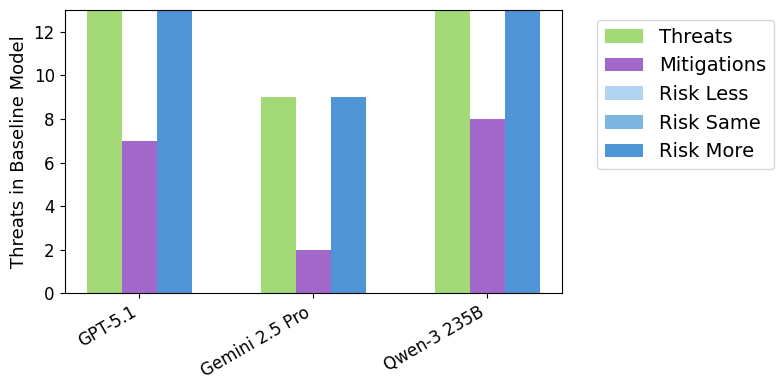

In [22]:
application = "message_queue_app"
base_model_dir = f"threat_templates/{application}"
results_dir = f"results/{application}"
stats_dir = f"stats/{application}"

get_unknown_assets(models, base_model_dir, results_dir)
threat_chart(base_model_dir, stats_dir, application)

{'Web Service', 'Web UI', 'PostgreSQL'}
--------------------------------------------------
Model: gpt_5_1
{'Credential', 'Compromise', 'CAs', 'Inability', 'Authentication', 'IDs', 'Java Web Container', 'Flooding', 'Web Service API', 'XML API', 'Network', 'Internet', 'Session', 'Potential', 'DDoS', 'Administrative', 'Crafted', 'Java Web Service', 'Standard', 'Exhaustion', 'JavaScript'}
--------------------------------------------------
Model: gemini_2_5_pro
{'Theft', 'JQuery', 'Cross', 'Java', 'Inability', 'They', 'JQuery Web UI', 'Due', 'Referer', 'Data', 'This'}
--------------------------------------------------
Model: qwen_3_235b_thinking
{'Disputed', 'Inability', 'Application', 'Session', 'Direct', 'External', 'IDs', 'Service', 'Data', 'Altered'}


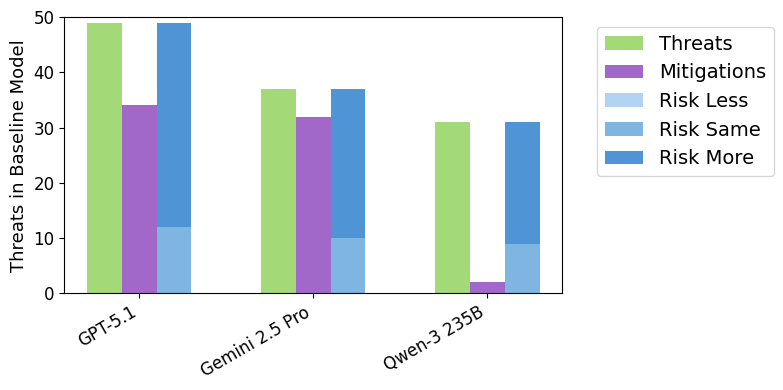

In [23]:
application = "web_app"
base_model_dir = f"threat_templates/{application}"
results_dir = f"results/{application}"
stats_dir = f"stats/{application}"

get_unknown_assets(models, base_model_dir, results_dir)
threat_chart(base_model_dir, stats_dir, application)

{'Azure Cognitive Service', 'Azure Storage', 'EdgeRuntime', 'IoTEdge Device', 'USB Video Camera', 'Browser', 'M1', 'M2', 'Application Insights', 'Azure IoT Hub', 'M3'}
--------------------------------------------------
Model: gpt_5_1
{'Connection', 'Debugging', 'Injection', 'Azure', 'Security', 'WebSocket', 'Large', 'Adversaries', 'Debug', 'Storage', 'GitHub', 'Configuration', 'Telemetry', 'Deployments', 'Continuous', 'Azure Application Insights', 'IoT', 'Modules', 'Edge', 'Speech', 'Hub', 'Cognitive Service', 'Text', 'IoT Hub'}
--------------------------------------------------
Model: gemini_2_5_pro
{'Speech', 'Middle', 'Cognitive Service', 'Azure', 'WebSocket', 'Confidential', 'Text', 'Azure Cognitive Services', 'IoT', 'Generation', 'Man', 'This', 'Cognitive Services', 'WebSockets', 'Theft'}
--------------------------------------------------
Model: qwen_3_235b_thinking
{'Connection', 'Speech', 'GitHub', 'EdgeMetricsCollector', 'Debugging', 'Azure', 'False', 'WebSocket', 'Session', 'T

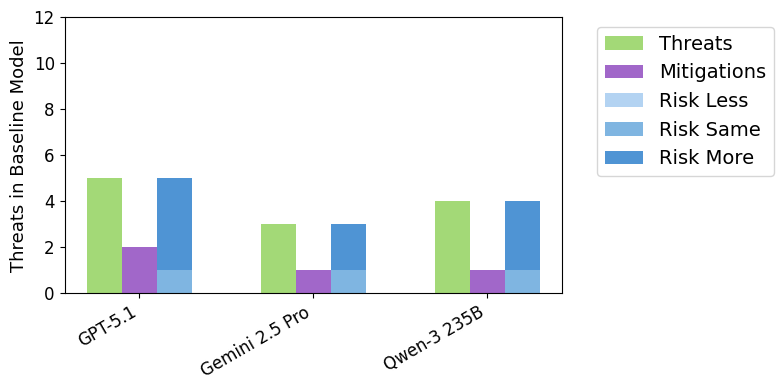

In [24]:
application = "iot"
base_model_dir = f"threat_templates/{application}"
results_dir = f"results/{application}"
stats_dir = f"stats/{application}"

get_unknown_assets(models, base_model_dir, results_dir)
threat_chart(base_model_dir, stats_dir, application)